In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xmf6
from denit import gwf, gwt, api, wma, plot
linea = 50*chr(0x2015)

In [2]:
# Encuentra el índice donde esta la cadena (ks) y salta (sK) al renglón donde comienza la info
find_index = lambda ls, ks, sk: [n for n, l in enumerate(ls) if ks in l][0] + sk

In [3]:
def get_head(o_sim_f):
# --- Recuperamos el nombre y el objeto del modelo de flujo
    flow_name = o_sim_f.model_names[0]
    o_gwf = o_sim_f.get_model(flow_name)
    #
    # --- Recuperamos los resultados de flujo de la simulación ---
    head = o_gwf.output.head().get_data() #(mflay=0)
    #
    # --- Recuperamos las coordenadas del dominio
    x, y, z = o_gwf.modelgrid.xyzcellcenters 
    return o_gwf, head, x, y, z

In [4]:
def get_conc(o_sim_t):
    # --- Recuperamos el nombre y el objeto del modelo de transporte
    tran_name = o_sim_t.model_names[0]
    o_gwt = o_sim_t.get_model(tran_name)

    # --- Recuperamos la lista de tiempos del modelo de transporte
    U_obj = o_gwt.output.concentration()
    time = U_obj.get_times()
    # --- Recuperamos los resultados de la concentración de la simulación ---
    # --- Ojo, usamos solo el primer tiempo
    return U_obj.get_data(totim=time[0])[0,0]

In [5]:
#
# --- DEFINICIÓN DE LAS RUTAS Y NOMBRES ---
#
paths = dict(
    # Ejecutable de Modflow: WINDOWS
    mf6_exe = r"C:\Users\luiggi\Documents\GitSites\mf6_tutorial\mf6\windows\mf6",
    mf6_dll = r"C:\Users\luiggi\Documents\GitSites\mf6_tutorial\mf6\windows\libmf6.dll",
    #
    # Nombre de los modelos y espacios de trabajo
    flow_name = "flow",
    flow_ws = "output_gwf_gwt_comp",
    tran_name = "transport",
    tran_ws = "output_gwf_gwt_comp"
)
xmf6.nice_print(paths, "Rutas y nombres de archivos")
#
# --- DATOS PARA LA SIMULACIÓN ---
#
# Número de componentes
ncomp = 7 
#
# Discretización del espacio
nlay, nrow, ncol = 1, 1, 10
delr, delc, delz = 0.10, 0.10, 0.10 
dis = {
    'length_units' : "meters",
    'nlay': nlay, 
    'nrow': nrow, 
    'ncol': ncol,
    'delr': delr, 
    'delc': delc, 
    'top' : delz, 
    'botm': 0.0 
}
xmf6.nice_print(dis, "Discretización espacial")
#
# Parámetros físicos.
#
# Leer información de "u_init.dat"
filename = "u_init.dat"

with open(filename, "r") as f:
    lines = f.readlines()
#
# Concentraciones iniciales de cada componente
key_string = "Aqueous component concentrations in the domain:"
icc = find_index(lines, key_string, 1)
comp_conc_list = [np.array(l.split(), dtype=float) for l in lines[icc:icc+ncomp]]
#
# Concentración de cada componente que proviene del exterior
key_string = "Aqueous component concentrations of external waters:"
iew = find_index(lines, key_string, 2)
comp_ext_water = [float(cw) for cw in lines[iew:iew+ncomp]]
#
# Parámetros físicos.
phys = dict(
    specific_discharge = 0.2,  # Specific discharge ($cm s^{-1}$)
    hydraulic_conductivity = 1.0,  # Hydraulic conductivity ($cm s^{-1}$)
    source_concentration = comp_ext_water,  # Source concentration (unitless)
    porosity = 0.5,  # Porosity of mobile domain (unitless)
    initial_concentration = comp_conc_list, # Initial concentration (unitless)
    longitudinal_dispersivity = 1.0,
)
xmf6.nice_print(phys, "Parámetros físicos")


Rutas y nombres de archivos
―――――――――――――――――――――――――――
  mf6_exe = C:\Users\luiggi\Documents\GitSites\mf6_tutorial\mf6\windows\mf6
  mf6_dll = C:\Users\luiggi\Documents\GitSites\mf6_tutorial\mf6\windows\libmf6.dll
flow_name = flow
  flow_ws = output_gwf_gwt_comp
tran_name = transport
  tran_ws = output_gwf_gwt_comp
―――――――――――――――――――――――――――

Discretización espacial
―――――――――――――――――――――――
length_units = meters
        nlay = 1
        nrow = 1
        ncol = 10
        delr = 0.1
        delc = 0.1
         top = 0.1
        botm = 0.0
―――――――――――――――――――――――

Parámetros físicos
――――――――――――――――――
       specific_discharge = 0.2
   hydraulic_conductivity = 1.0
     source_concentration = ―― data array ――
                          = -2.51155e-06
                          = 0.001
                          = 0.001
                          = 1e-16
                          = 0.002
                          = 0.000540132
                          = 0.000252947
                 porosity

In [6]:
#
# - SIMULACIÓN DE FLUJO CON GWF ---
#
# --- Construcción de la simulación de flujo
o_sim_f = gwf.build(phys, dis, 0, paths)
#
# --- Ejecución de la simulación ---
print("- Ejecutando GWF")
o_sim_f.run_simulation(silent=True)
#
# --- Recuperamos los resultados de GWF ---
o_gwf, head, x, y, z = get_head(o_sim_f)

――――――――――――――――――――――――――――――――――――――――――――――――――
- Escribiendo archivos de entrada para GWF
- Ejecutando GWF


(True, [])

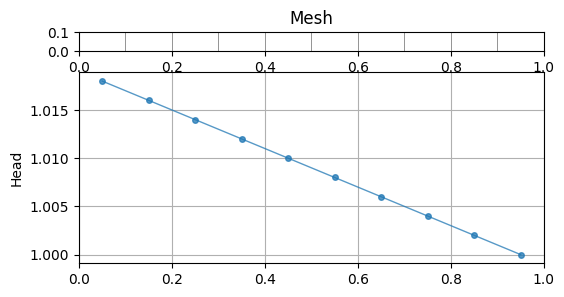

In [13]:
plot.show_f(o_gwf, head, x, y, z)

In [16]:
U = []
for m in range(0, ncomp):
    #
    # - SIMULACIÓN DE FLUJO CON GWF ---
    #
    # --- Construcción de la simulación de flujo
    o_sim_f = gwf.build(phys, dis, m, paths)
    #
    # --- Ejecución de la simulación ---
    print("- Ejecutando GWF")
    o_sim_f.run_simulation(silent=True)
#    _, head, _, _, _ = get_head(o_sim_f)
    print(m)
    print(head)
    #
    # - SIMULACIÓN DE TRANSPORTE CON GWT PARA CADA COMPONENTE
    #
    # --- Construcción de la simulación de flujo
    o_sim_t = gwt.build(phys, dis, m, paths)
    #
    # --- Ejecución de la simulación ---
    print(f"- Ejecutando GWT - componente C{m}")
    o_sim_t.run_simulation(silent=True)
    #
    #
    U.append(get_conc(o_sim_t))

――――――――――――――――――――――――――――――――――――――――――――――――――
- Escribiendo archivos de entrada para GWF
- Ejecutando GWF
0
[[[1.018 1.016 1.014 1.012 1.01  1.008 1.006 1.004 1.002 1.   ]]]
――――――――――――――――――――――――――――――――――――――――――――――――――
- Escribiendo archivos de entrada para GWT
- Ejecutando GWT - componente C0
――――――――――――――――――――――――――――――――――――――――――――――――――
- Escribiendo archivos de entrada para GWF
- Ejecutando GWF
1
[[[1.018 1.016 1.014 1.012 1.01  1.008 1.006 1.004 1.002 1.   ]]]
――――――――――――――――――――――――――――――――――――――――――――――――――
- Escribiendo archivos de entrada para GWT
- Ejecutando GWT - componente C1
――――――――――――――――――――――――――――――――――――――――――――――――――
- Escribiendo archivos de entrada para GWF
- Ejecutando GWF
2
[[[1.018 1.016 1.014 1.012 1.01  1.008 1.006 1.004 1.002 1.   ]]]
――――――――――――――――――――――――――――――――――――――――――――――――――
- Escribiendo archivos de entrada para GWT
- Ejecutando GWT - componente C2
――――――――――――――――――――――――――――――――――――――――――――――――――
- Escribiendo archivos de entra

In [14]:
print(U)

[array([-3.69546993e-07, -3.69364209e-07, -3.69246949e-07, -3.69172450e-07,
       -3.69126364e-07, -3.69100011e-07, -3.69088775e-07, -3.69091359e-07,
       -3.69109791e-07, -3.69150263e-07]), array([1.41134175e-04, 9.10801688e-05, 5.87908044e-05, 3.79702047e-05,
       2.45600962e-05, 1.59490008e-05, 1.04640462e-05, 7.04660763e-06,
       5.04907712e-06, 4.11406284e-06]), array([1.49707346e-04, 1.00159372e-04, 6.81964450e-05, 4.75863360e-05,
       3.43118001e-05, 2.57877607e-05, 2.03582575e-05, 1.69753683e-05,
       1.49980323e-05, 1.40724708e-05]), array([1.e-16, 1.e-16, 1.e-16, 1.e-16, 1.e-16, 1.e-16, 1.e-16, 1.e-16,
       1.e-16, 1.e-16]), array([2.92012756e-04, 1.91995392e-04, 1.27475139e-04, 8.58716454e-05,
       5.90757141e-05, 4.18691181e-05, 3.09091420e-05, 2.40804539e-05,
       2.00890104e-05, 1.82206751e-05]), array([0.00093677, 0.00095936, 0.00097393, 0.00098333, 0.00098938,
       0.00099327, 0.00099575, 0.00099729, 0.00099819, 0.00099861]), array([3.40773161e-05, 2.

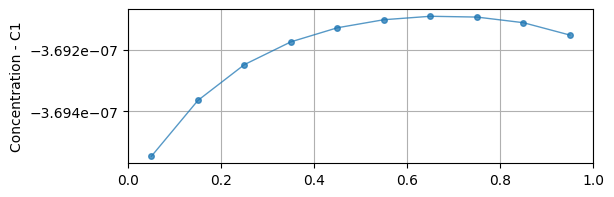

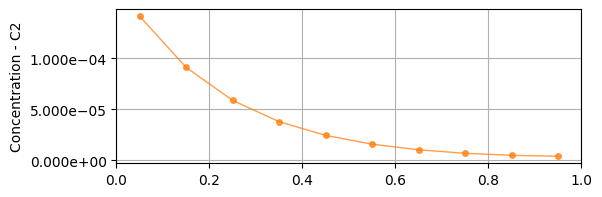

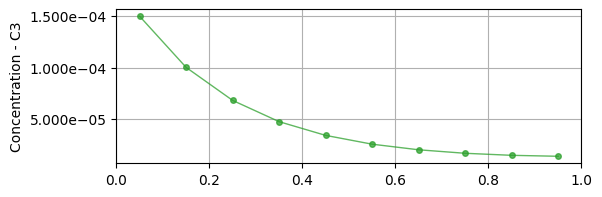

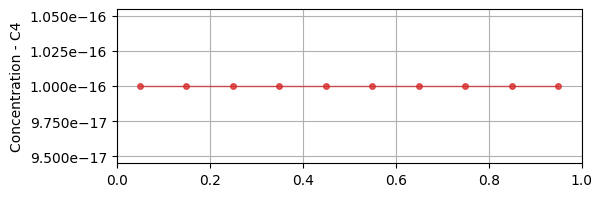

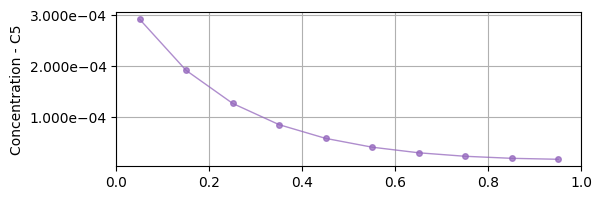

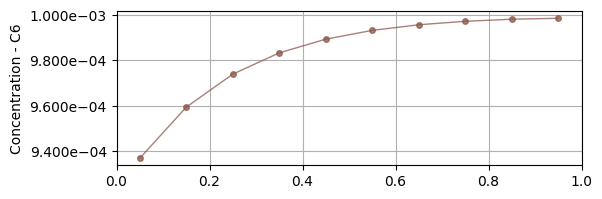

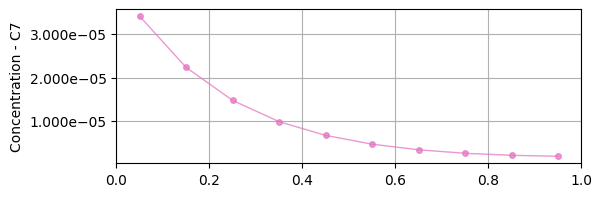

In [15]:
for m in range(0, ncomp):
    plot.show_t(U[m], m, x, y, z)